<a href="https://colab.research.google.com/github/nandadwilestari/Data-Mining/blob/main/visualisasi_chart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Selamat Datang di Colab!

## Google Colab tersedia di VS Code.
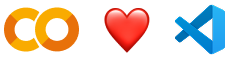

Coba <a href="https://marketplace.visualstudio.com/items?itemName=Google.colab">ekstensi Google Colab</a> yang baru untuk Visual Studio Code. Anda dapat mulai menjalankannya hanya dengan beberapa klik:

*  Di VS Code, buka tampilan <strong><em>Extensions</em></strong> dan telusuri 'Google Colab' untuk menginstalnya.
*  Buka pemilih kernel dengan membuat atau membuka file notebook berformat <code>.ipynb</code> di ruang kerja lokal Anda. Kemudian, jalankan sel atau klik tombol <strong><em>Select Kernel</em></strong> di kanan atas.
*  Klik <strong><em>Colab</em></strong>, lalu pilih runtime yang Anda inginkan, login dengan Akun Google Anda, dan selesai.

Lihat detail selengkapnya di <a href="https://developers.googleblog.com/google-colab-is-coming-to-vs-code">blog pengumuman kami di sini</a>.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving movie_metadata.csv to movie_metadata.csv


In [ ]:
import pandas as pd

df = pd.read_csv('movie_metadata.csv')

df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


Informasi Dataset:
Jumlah baris: 5043
Jumlah kolom: 28

5 baris pertama:
   color      director_name  num_critic_for_reviews  duration  \
0  Color      James Cameron                   723.0     178.0   
1  Color     Gore Verbinski                   302.0     169.0   
2  Color         Sam Mendes                   602.0     148.0   
3  Color  Christopher Nolan                   813.0     164.0   
4    NaN        Doug Walker                     NaN       NaN   

   director_facebook_likes  actor_3_facebook_likes      actor_2_name  \
0                      0.0                   855.0  Joel David Moore   
1                    563.0                  1000.0     Orlando Bloom   
2                      0.0                   161.0      Rory Kinnear   
3                  22000.0                 23000.0    Christian Bale   
4                    131.0                     NaN        Rob Walker   

   actor_1_facebook_likes        gross                           genres  ...  \
0                  1000

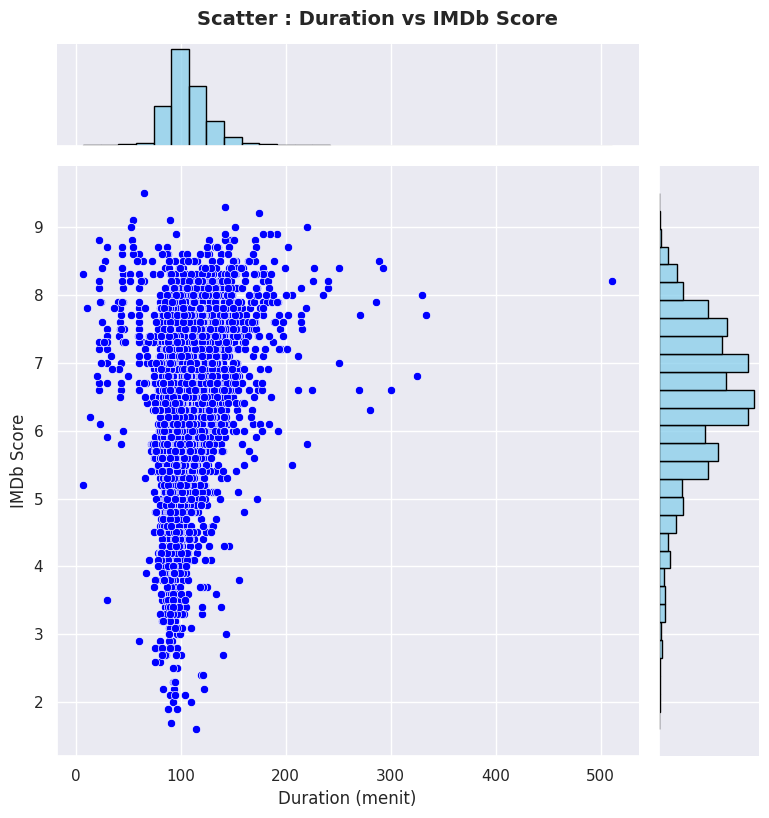

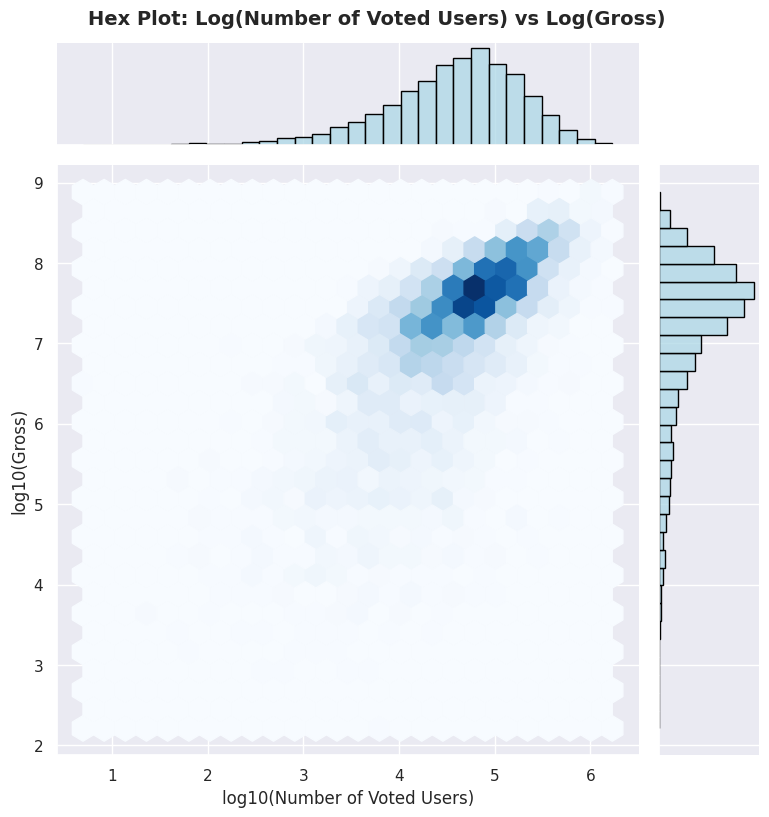

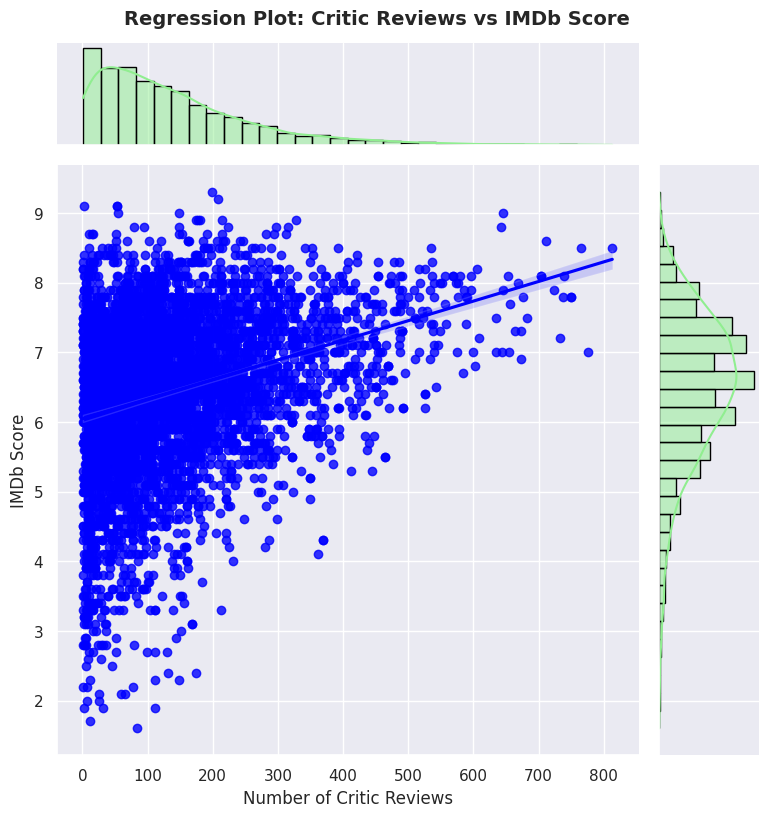

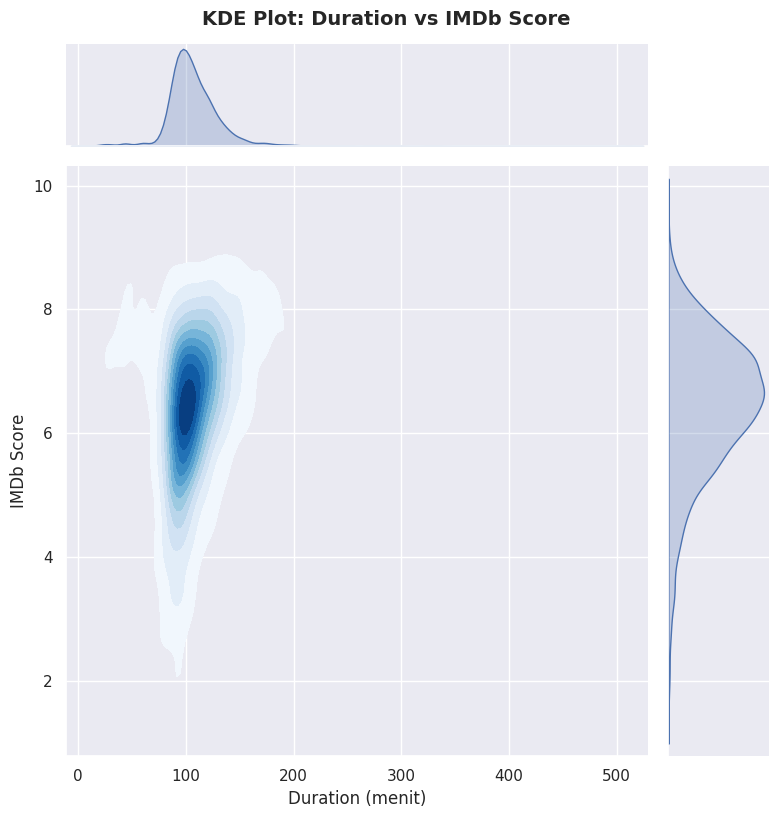

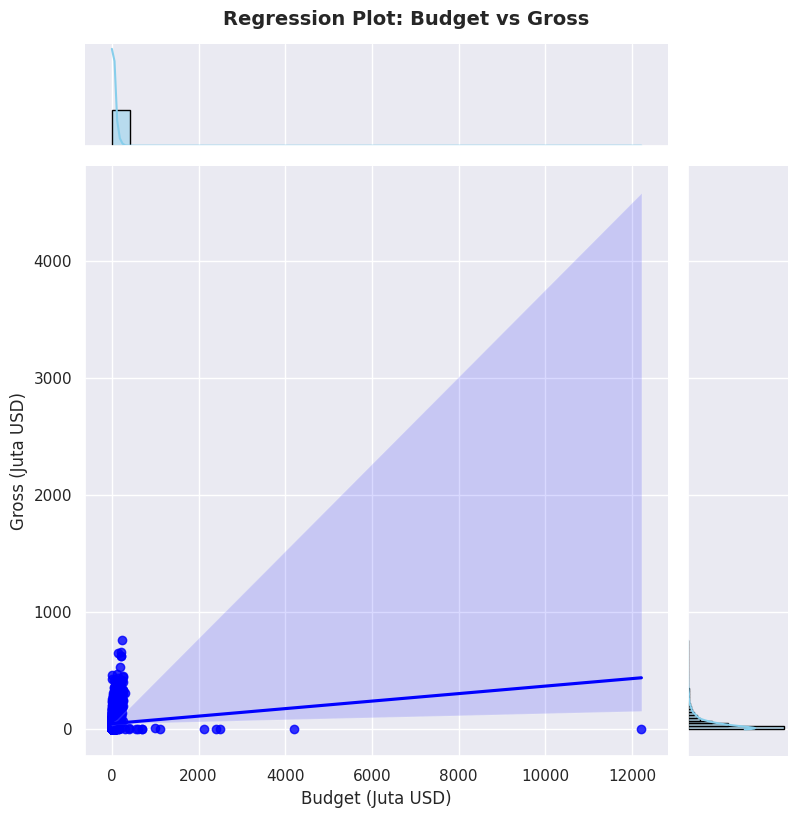


STATISTIK KORELASI
Korelasi Duration vs IMDb Score: 0.262
Korelasi Number of Voted Users vs Gross: 0.637
Korelasi Critic Reviews vs IMDb Score: 0.305
Korelasi Budget vs Gross: 0.102

Visualisasi selesai!


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('movie_metadata.csv')

# =========================
# INFORMASI DATASET
# =========================
print("Informasi Dataset:")
print(f"Jumlah baris: {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")

print("\n5 baris pertama:")
print(df.head())

print("\nKolom yang tersedia:")
print(df.columns.tolist())

# Style
sns.set_theme(style="darkgrid")

# =========================================================
# 1. SCATTER : Duration vs IMDb Score
# =========================================================
df_scatter = df.dropna(subset=['duration', 'imdb_score']).copy()

g1 = sns.jointplot(
    data=df_scatter,
    x='duration',
    y='imdb_score',
    kind='scatter',
    height=8,
    color='blue',
    marginal_kws=dict(bins=30, fill=True, color='skyblue', edgecolor='black')
)

g1.fig.suptitle('Scatter : Duration vs IMDb Score', y=1.02, fontsize=14, fontweight='bold')
g1.set_axis_labels('Duration (menit)', 'IMDb Score')
plt.show()


# =========================================================
# 2. HEX: Number of Voted Users vs Gross
#    Pakai log biar lebih jelas
# =========================================================
df_hex = df.dropna(subset=['num_voted_users', 'gross']).copy()
df_hex = df_hex[(df_hex['num_voted_users'] > 0) & (df_hex['gross'] > 0)]

df_hex['log_num_voted_users'] = np.log10(df_hex['num_voted_users'])
df_hex['log_gross'] = np.log10(df_hex['gross'])

g2 = sns.jointplot(
    data=df_hex,
    x='log_num_voted_users',
    y='log_gross',
    kind='hex',
    height=8,
    gridsize=25,
    cmap='Blues',
    marginal_kws=dict(bins=30, fill=True, color='lightblue', edgecolor='black')
)

g2.fig.suptitle('Hex Plot: Log(Number of Voted Users) vs Log(Gross)', y=1.02, fontsize=14, fontweight='bold')
g2.set_axis_labels('log10(Number of Voted Users)', 'log10(Gross)')
plt.show()


# =========================================================
# 3. REG: Number of Critic Reviews vs IMDb Score
# =========================================================
df_reg = df.dropna(subset=['num_critic_for_reviews', 'imdb_score']).copy()

g3 = sns.jointplot(
    data=df_reg,
    x='num_critic_for_reviews',
    y='imdb_score',
    kind='reg',
    height=8,
    color='blue',
    marginal_kws=dict(bins=30, fill=True, color='lightgreen', edgecolor='black')
)

g3.fig.suptitle('Regression Plot: Critic Reviews vs IMDb Score', y=1.02, fontsize=14, fontweight='bold')
g3.set_axis_labels('Number of Critic Reviews', 'IMDb Score')
plt.show()


# =========================================================
# 4. KDE: Duration vs IMDb Score
# =========================================================
df_kde = df.dropna(subset=['duration', 'imdb_score']).copy()

g4 = sns.jointplot(
    data=df_kde,
    x='duration',
    y='imdb_score',
    kind='kde',
    fill=True,
    cmap='Blues',
    height=8,
    levels=12,
    thresh=0.05
)

g4.fig.suptitle('KDE Plot: Duration vs IMDb Score', y=1.02, fontsize=14, fontweight='bold')
g4.set_axis_labels('Duration (menit)', 'IMDb Score')
plt.show()


# =========================================================
# 5. REGRESI LINEAR TAMBAHAN: Budget vs Gross
#    Supaya mirip dengan ide kode awal Anda
# =========================================================
df_budget_gross = df.dropna(subset=['budget', 'gross']).copy()
df_budget_gross = df_budget_gross[(df_budget_gross['budget'] > 0) & (df_budget_gross['gross'] > 0)]

df_budget_gross['Budget (Juta USD)'] = df_budget_gross['budget'] / 1_000_000
df_budget_gross['Gross (Juta USD)'] = df_budget_gross['gross'] / 1_000_000

g5 = sns.jointplot(
    data=df_budget_gross,
    x='Budget (Juta USD)',
    y='Gross (Juta USD)',
    kind='reg',
    height=8,
    color='blue',
    marginal_kws=dict(bins=30, fill=True, color='skyblue', edgecolor='black')
)

g5.fig.suptitle('Regression Plot: Budget vs Gross', y=1.02, fontsize=14, fontweight='bold')
g5.set_axis_labels('Budget (Juta USD)', 'Gross (Juta USD)')
plt.show()


# =========================================================
# STATISTIK KORELASI
# =========================================================
print("\n" + "="*60)
print("STATISTIK KORELASI")
print("="*60)

corr_duration_score = df_scatter[['duration', 'imdb_score']].corr().iloc[0, 1]
corr_voted_gross = df_hex[['num_voted_users', 'gross']].corr().iloc[0, 1]
corr_critic_score = df_reg[['num_critic_for_reviews', 'imdb_score']].corr().iloc[0, 1]
corr_budget_gross = df_budget_gross[['budget', 'gross']].corr().iloc[0, 1]

print(f"Korelasi Duration vs IMDb Score: {corr_duration_score:.3f}")
print(f"Korelasi Number of Voted Users vs Gross: {corr_voted_gross:.3f}")
print(f"Korelasi Critic Reviews vs IMDb Score: {corr_critic_score:.3f}")
print(f"Korelasi Budget vs Gross: {corr_budget_gross:.3f}")

print("\nVisualisasi selesai!")

Colab kini memiliki fitur AI yang didukung oleh <a href="https://gemini.google.com">Gemini</a>. Video berikut memberikan informasi tentang cara menggunakan fitur ini, baik jika Anda baru mengenal Python, atau sudah berpengalaman.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  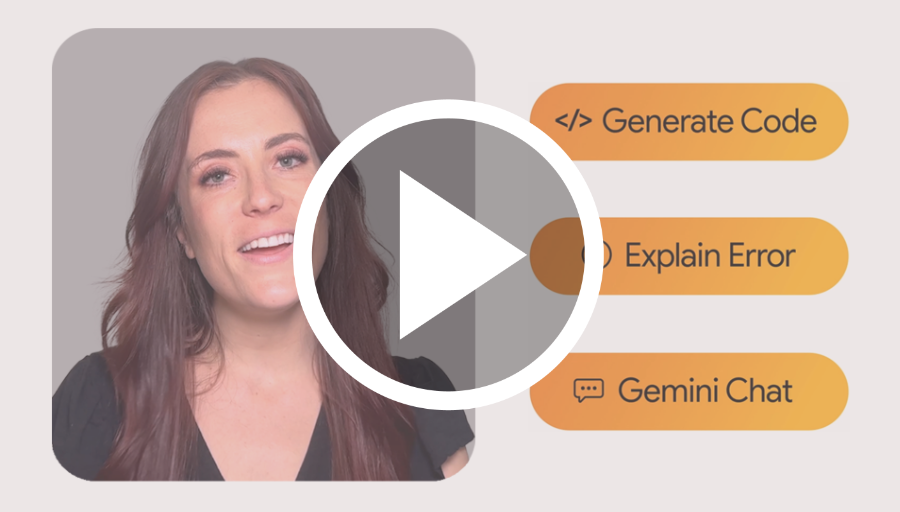
  </a>
</center>

<div class="markdown-google-sans">
  <h2>Apa itu Colab?</h2>
</div>

Colab, atau "Colaboratory", memungkinkan Anda menulis dan mengeksekusi Python di browser, dengan
- Tidak memerlukan konfigurasi
- Akses tanpa biaya ke GPU
- Berbagi dengan mudah

Baik Anda seorang <strong>siswa</strong>, <strong>data scientist</strong>, atau <strong>peneliti AI</strong>, Colab dapat memudahkan pekerjaan Anda. Tonton <a href="https://www.youtube.com/watch?v=inN8seMm7UI">Pengantar Colab</a> atau <a href="https://www.youtube.com/watch?v=rNgswRZ2C1Y">Fitur Colab yang Mungkin Belum Anda Ketahui</a> untuk mempelajari lebih lanjut, atau cukup mulai di bawah ini.

<div class="markdown-google-sans">

## <strong>Memulai</strong>
</div>

Dokumen yang sedang Anda baca bukan halaman statis. Ini media interaktif bernama <strong>notebook Colab</strong> yang memungkinkan Anda menulis dan mengeksekusi kode.

Misalnya, berikut ini <strong>kode sel</strong> dengan skrip Python pendek yang mengomputasi sebuah nilai, menyimpannya dalam suatu variabel, dan mencetak hasilnya:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

Untuk mengeksekusi kode dalam sel di atas, pilih kode tersebut dengan mengkliknya, kemudian tekan tombol putar di sebelah kiri kode atau gunakan pintasan keyboard "Command/Ctrl+Enter". Untuk mengedit kode, cukup klik sel dan mulai pengeditan.

Variabel yang Anda tentukan dalam sebuah sel nantinya dapat digunakan di sel lain:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Notebook Colab memungkinkan Anda menggabungkan <strong>kode yang dapat dijalankan</strong> dan <strong>rich text</strong> dalam satu dokumen, beserta <strong>gambar</strong>, <strong>HTML</strong>, <strong>LaTeX</strong>, dan lainnya. Saat Anda membuat notebook Colab Anda sendiri, notebook tersebut akan disimpan di akun Google Drive Anda. Anda dapat dengan mudah membagikan notebook Colab Anda dengan rekan kerja atau teman, sehingga memungkinkan mereka memberikan komentar di notebook Anda atau bahkan mengeditnya. Untuk mempelajari lebih lanjut, buka <a href="/notebooks/basic_features_overview.ipynb">Ringkasan Colab</a>. Untuk membuat notebook Colab baru, Anda dapat menggunakan menu File di atas, atau menggunakan link berikut: <a href="http://colab.research.google.com#create=true">buat notebook Colab baru</a>.

Notebook Colab adalah notebook Jupyter yang dihosting oleh Colab. Untuk mempelajari project Jupyter lebih lanjut, buka <a href="https://www.jupyter.org">jupyter.org</a>.

<div class="markdown-google-sans">

## Ilmu data
</div>

Dengan Colab, Anda dapat memanfaatkan kecanggihan library Python yang populer untuk menganalisis dan memvisualisasikan data. Sel kode di bawah menggunakan <strong>numpy</strong> untuk menghasilkan beberapa data acak, dan menggunakan <strong>matplotlib</strong> untuk memvisualisasikannya. Untuk mengedit kode, cukup klik sel dan mulai pengeditan.

Anda dapat mengimpor data sendiri ke notebook Colab dari akun Google Drive Anda, termasuk dari spreadsheet, GitHub, dan berbagai sumber lainnya. Untuk mempelajari lebih lanjut pengimporan data dan bagaimana Colab dapat digunakan untuk ilmu data, lihat link di bawah pada bagian <a href="#working-with-data">Bekerja dengan Data</a>.

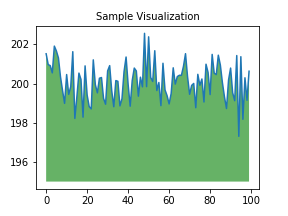

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Notebook Colab mengeksekusi kode di server cloud Google. Artinya, Anda dapat memanfaatkan kecanggihan hardware Google, termasuk <a href="#using-accelerated-hardware">GPU dan TPU</a>, terlepas dari kecanggihan komputer Anda. Yang Anda butuhkan hanyalah browser.

Misalnya, jika Anda harus menunggu kode <strong>pandas</strong> selesai dijalankan dan ingin mempercepat prosesnya, Anda dapat beralih ke Runtime GPU dan menggunakan library seperti <a href="https://rapids.ai/cudf-pandas">RAPIDS cuDF</a> yang menyediakan akselerasi tanpa perubahan kode.

Untuk mempelajari lebih lanjut cara mempercepat pandas di Colab, lihat <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb">panduan 10 menit</a> atau
 <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb">demo analisis data pasar saham AS</a>.

<div class="markdown-google-sans">

## Machine learning
</div>

Dengan Colab, Anda dapat mengimpor set data gambar, melatih pengklasifikasi gambar di dalamnya, dan mengevaluasi model hanya dengan <a href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb">beberapa baris kode</a>.

Colab digunakan secara luas di komunitas machine learning dengan berbagai penerapan meliputi:
- Memulai TensorFlow
- Mengembangkan dan melatih jaringan neural
- Bereksperimen dengan TPU
- Menyebarkan riset AI
- Membuat tutorial

Untuk melihat sampel notebook Colab yang menunjukkan penerapan machine learning, lihat <a href="#machine-learning-examples">contoh machine learning</a> di bawah.

<div class="markdown-google-sans">

## Referensi Lainnya

### Bekerja dengan Notebook di Colab

</div>

- [Ringkasan Colab](/notebooks/basic_features_overview.ipynb)
- [Panduan tentang Markdown](/notebooks/markdown_guide.ipynb)
- [Mengimpor library dan menginstal dependensi](/notebooks/snippets/importing_libraries.ipynb)
- [Menyimpan dan memuat notebook di GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Formulir interaktif](/notebooks/forms.ipynb)
- [Widget interaktif](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Bekerja dengan Data
</div>

- [Memuat data: Drive, Spreadsheet, dan Google Cloud Storage](/notebooks/io.ipynb)
- [Diagram: memvisualisasikan data](/notebooks/charts.ipynb)
- [Memulai BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

Berikut beberapa notebook yang terkait dengan Machine Learning, termasuk kursus Machine Learning online Google. Buka <a href="https://developers.google.com/machine-learning/crash-course/">situs kursus lengkap</a> untuk mengetahui info selengkapnya.
- [Pengantar Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Pengantar RAPIDS cuDF untuk mempercepat pandas](https://nvda.ws/rapids-cudf)
- [Mulai menggunakan mode akselerator cuML](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Menggunakan Hardware yang Diakselerasi
</div>

- [Melatih CNN untuk mengklasifikasikan angka dari tulisan tangan pada set data MNIST menggunakan Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Melatih Vision Transformer &#40;ViT&#41; untuk klasifikasi gambar dengan JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Klasifikasi teks dengan model bahasa transformer menggunakan JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Contoh bagus

</div>

- <a href="https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html">Melatih model bahasa miniGPT dengan Stack AI JAX</a>
- <a href="https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb">Fine-tuning LoRA/QLoRA untuk LLM menggunakan Tunix</a>
- <a href="https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/">Parameter-efficient fine-tuning &#40;PEFT&#41; Gemma dengan LoRA dan QLoRA</a>
- <a href="https://keras.io/keras_hub/guides/hugging_face_keras_integration/">Memuat Checkpoint Hugging Face Transformer</a>
- <a href="https://keras.io/guides/int8_quantization_in_keras/">Kuantisasi Bilangan Bulat 8-bit di Keras</a>
- <a href="https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/">Pelatihan dan inferensi Float8 dengan model Transformer sederhana</a>
- <a href="https://keras.io/keras_hub/guides/transformer_pretraining/">Melakukan pra-pelatihan Transformer dari awal dengan KerasHub</a>
- <a href="https://keras.io/examples/vision/mnist_convnet/">Convnet MNIST sederhana</a>
- <a href="https://keras.io/examples/vision/image_classification_from_scratch/">Klasifikasi gambar dari awal menggunakan Keras 3</a>
- <a href="https://keras.io/keras_hub/guides/classification_with_keras_hub/">Klasifikasi Gambar dengan KerasHub</a>
